# How to Parrallelize Bulk Text Embeddings Load on Snowflake

### Import snowpark libraries

In [3]:
from snowflake.snowpark import Session
from snowflake.snowpark.functions import col, max as _max
import json
import pandas as pd

In [4]:
# !pip install snowflake-snowpark-python
# !pip install notebook
# !pip install snowflake-ml-python

### Connect to Snowflake with a Snowpark Session

In [5]:
with open('creds.json') as f:
    data = json.load(f)
    USERNAME = data['username']
    PASSWORD = data['password']
    ROLE = data['role']
    ACCOUNT = data['account']
    WAREHOUSE = data['warehouse']
    DATABASE = data['database']
    SCHEMA = data['schema']

CONNECTION_PARAMETERS = {
   "account": ACCOUNT,
   "user": USERNAME,
   "password": PASSWORD,
   "role": ROLE, 
   "database": DATABASE,
   "warehouse": WAREHOUSE,
   "schema": SCHEMA
}

session = Session.builder.configs(CONNECTION_PARAMETERS).create()
session.get_current_warehouse()

'"XS_WH"'

### Create this SP directly on Snowflake worksheet

In [8]:
# '''
# create or replace procedure pdf_text_chunker(file_url string,relative_path string, size int, table_name string)
# returns string
# language python
# runtime_version = '3.9'
# handler = 'main'
# packages = ('snowflake-snowpark-python','PyPDF2', 'langchain')
# as
# $$
# from snowflake.snowpark import Session
# from snowflake.snowpark.types import StringType, StructField, StructType
# from langchain.text_splitter import RecursiveCharacterTextSplitter
# from snowflake.snowpark.files import SnowflakeFile
# import PyPDF2, io
# import logging
# import pandas as pd


# def read_pdf(file_url: str) -> str:

#     logger = logging.getLogger("udf_logger")
#     logger.info(f"Opening file {file_url}")

#     with SnowflakeFile.open(file_url, 'rb') as f:
#         buffer = io.BytesIO(f.readall())
        
#     reader = PyPDF2.PdfReader(buffer)   
#     text = ""
#     for page in reader.pages:
#         try:
#             text += page.extract_text().replace('\n', ' ').replace('\0', ' ')
#         except:
#             text = "Unable to Extract"
#             logger.warn(f"Unable to extract from file {file_url}, page {page}")
    
#     return text
    
# def main(session:Session, file_url,relative_path,size,table_name):
#         text = read_pdf(file_url)
#         text_splitter = RecursiveCharacterTextSplitter(
#             chunk_size = 4000, #Adjust this as you see fit
#             chunk_overlap  = 400, #This let's text have some form of overlap. Useful for keeping chunks contextual
#             length_function = len
#         )
#         chunks = text_splitter.split_text(text)
#         df = pd.DataFrame(chunks, columns=['chunks'])
#         df['RELATIVE_PATH'] = relative_path
#         df['SIZE'] = size
#         df =df[['RELATIVE_PATH','SIZE','chunks']]
#         session.write_pandas(df,table_name,auto_create_table=True, table_type="transient",overwrite=True)
#         return 'Done'
# $$;'''

In [9]:
# '''
# CREATE OR REPLACE PROCEDURE insert_embeddings(table_name varchar, temp_table_name varchar)
# RETURNS BOOLEAN
# LANGUAGE SQL
# AS
# DECLARE
# model varchar DEFAULT '''e5-base-v2''';
# insert_embeddings VARCHAR DEFAULT 
# 'insert into '||:table_name||' select RELATIVE_PATH,SIZE, "chunks", snowflake.cortex.embed_text('||:model||', "chunks") as chunk_embedding from '||:temp_table_name||';';
# BEGIN
#   execute immediate :insert_embeddings using(table_name,temp_table_name);
#   RETURN TRUE;
#   -- Need to return something... true boolean for now.
# END;
# '''

### Create the number of warehouse batches and bucket size per Warehouse. 
##### Recommend to atleast operate on 30 warehouses
##### Make sure you atleast have 80 tasks per parent (wrhs)

In [10]:
session.sql ("set wrhs_batch_size = 5;").collect()
session.sql ("set bucket_size = 80;").collect()
generate_matrix = '''
create OR REPLACE table to_process AS 
select b.wrhs_batch,a.bucket,a.relative_path,a.size,'NOT PROCESSED' STATUS
from
(select  NTILE($wrhs_batch_size*$bucket_size) OVER (ORDER BY relative_path) AS bucket,relative_path,size from DIRECTORY(@RAG_DOCS)) a
join
(SELECT  NTILE($wrhs_batch_size) OVER (ORDER BY relative_path) AS wrhs_batch,relative_path,size FROM DIRECTORY(@RAG_DOCS)) b
on a.relative_path = b.relative_path;'''
session.sql (generate_matrix).collect()

[Row(status='Table TO_PROCESS successfully created.')]

### Create the batches alligning to the number of warehouses

In [11]:
batch = session.sql("select distinct wrhs_batch from to_process").to_pandas()

In [12]:
warehouse_create = '''CREATE OR REPLACE WAREHOUSE WRHS_PDF_CHUNK_{0} 
  WAREHOUSE_TYPE = 'STANDARD'
  WAREHOUSE_SIZE = 'SMALL'
  AUTO_SUSPEND = 1800
  MAX_CLUSTER_COUNT = 10
  MIN_CLUSTER_COUNT = 1
  MAX_CONCURRENCY_LEVEL = 24
  SCALING_POLICY = STANDARD;
  '''
for index, row in batch.iterrows():
    session.sql(warehouse_create.format(row['WRHS_BATCH'])).collect()

In [13]:
# base_chunks_table = '''create or replace TRANSIENT TABLE TEST_CHUNKS{0} (
#     RELATIVE_PATH VARCHAR,
#     SIZE NUMBER(38,0),
#     "chunks" VARCHAR
# );'''
# for index, row in batch.iterrows():
#     session.sql(base_chunks_table.format(row['WRHS_BATCH'])).collect()

### Create the test chunks tables where the embeddings will be stored

In [14]:
base_chunks_table = '''create or replace TRANSIENT TABLE TEST_CHUNKS (
    RELATIVE_PATH VARCHAR,
    SIZE NUMBER(38,0),
    "chunks" VARCHAR,
    chunk_embedding VECTOR(FLOAT, 768)
);'''
session.sql(base_chunks_table).collect()

[Row(status='Table TEST_CHUNKS successfully created.')]

### Create as many root pdf chunk tasks per warehouse.

In [15]:
base_parent_task = '''CREATE OR REPLACE TASK ROOT_PDF_CHUNK{0}
  user_task_timeout_ms = 18000000
  WAREHOUSE = WRHS_PDF_CHUNK_{0} 
  SCHEDULE = '5 minute'
  AS
    SELECT CURRENT_TIME;'''
# for row in batch.to_local_iterator():
for index, row in batch.iterrows():
    session.sql(base_parent_task.format(row['WRHS_BATCH'])).collect()

### Create the bucketized tasks per parent root task

In [16]:
to_process = session.sql("select distinct wrhs_batch, bucket from to_process").to_pandas()

### TEMPLATE TO EXECUTE 20 TASKS CONCURRENTLY TO AVOID STATEMENT LIMIT TIMEOUT ISSUE. IF 20 IS CAUSING FAILURES, REDUCE TO 10 CONCURRENCY BY UPDATING THE CSV

In [17]:
exec_df = pd.read_csv("execution20202020.csv").sort_values(by=['execution', 'wrhs_batch', 'BUCKET','task','Dependency'])

### BASE CHILD TASK TO SET UP DEPENDENCY AND CREATE THE TASKS FOR EACH WAREHOUSE AND BUCKET

In [18]:
base_child_task = '''CREATE OR REPLACE TASK {1}
  WAREHOUSE = WRHS_PDF_CHUNK_{0}
  user_task_timeout_ms = 18000000
  AFTER {2}
AS
BEGIN
    LET c1 CURSOR FOR SELECT * FROM TO_PROCESS WHERE WRHS_BATCH = {0} AND BUCKET = {3};
    FOR record IN c1 DO
        LET relative_path VARCHAR := record.relative_path;
        LET size INT := record.size;
        CALL pdf_text_chunker(BUILD_SCOPED_FILE_URL(@RAG_DOCS,:relative_path),:relative_path,:size, 'TEST_CHUNKS_{1}');
        CALL insert_embeddings('TEST_CHUNKS','TEST_CHUNKS_{1}');
    END FOR;
END;'''

In [19]:
# exec_df = pd.read_csv("execution.csv").sort_values(by=['execution', 'wrhs_batch', 'BUCKET','task','Dependency'])
for index, row in exec_df.iterrows():
    if 'ROOT' in row['Dependency']:
        pref = ''
    else:
        pref ='WRHS'+str(row['wrhs_batch'])+'_'
    session.sql(base_child_task.format(row['wrhs_batch'],'WRHS'+str(row['wrhs_batch'])+ '_'+row['task'],pref+row['Dependency'], row['BUCKET'])).collect()

### DAG of tasks display under the Database

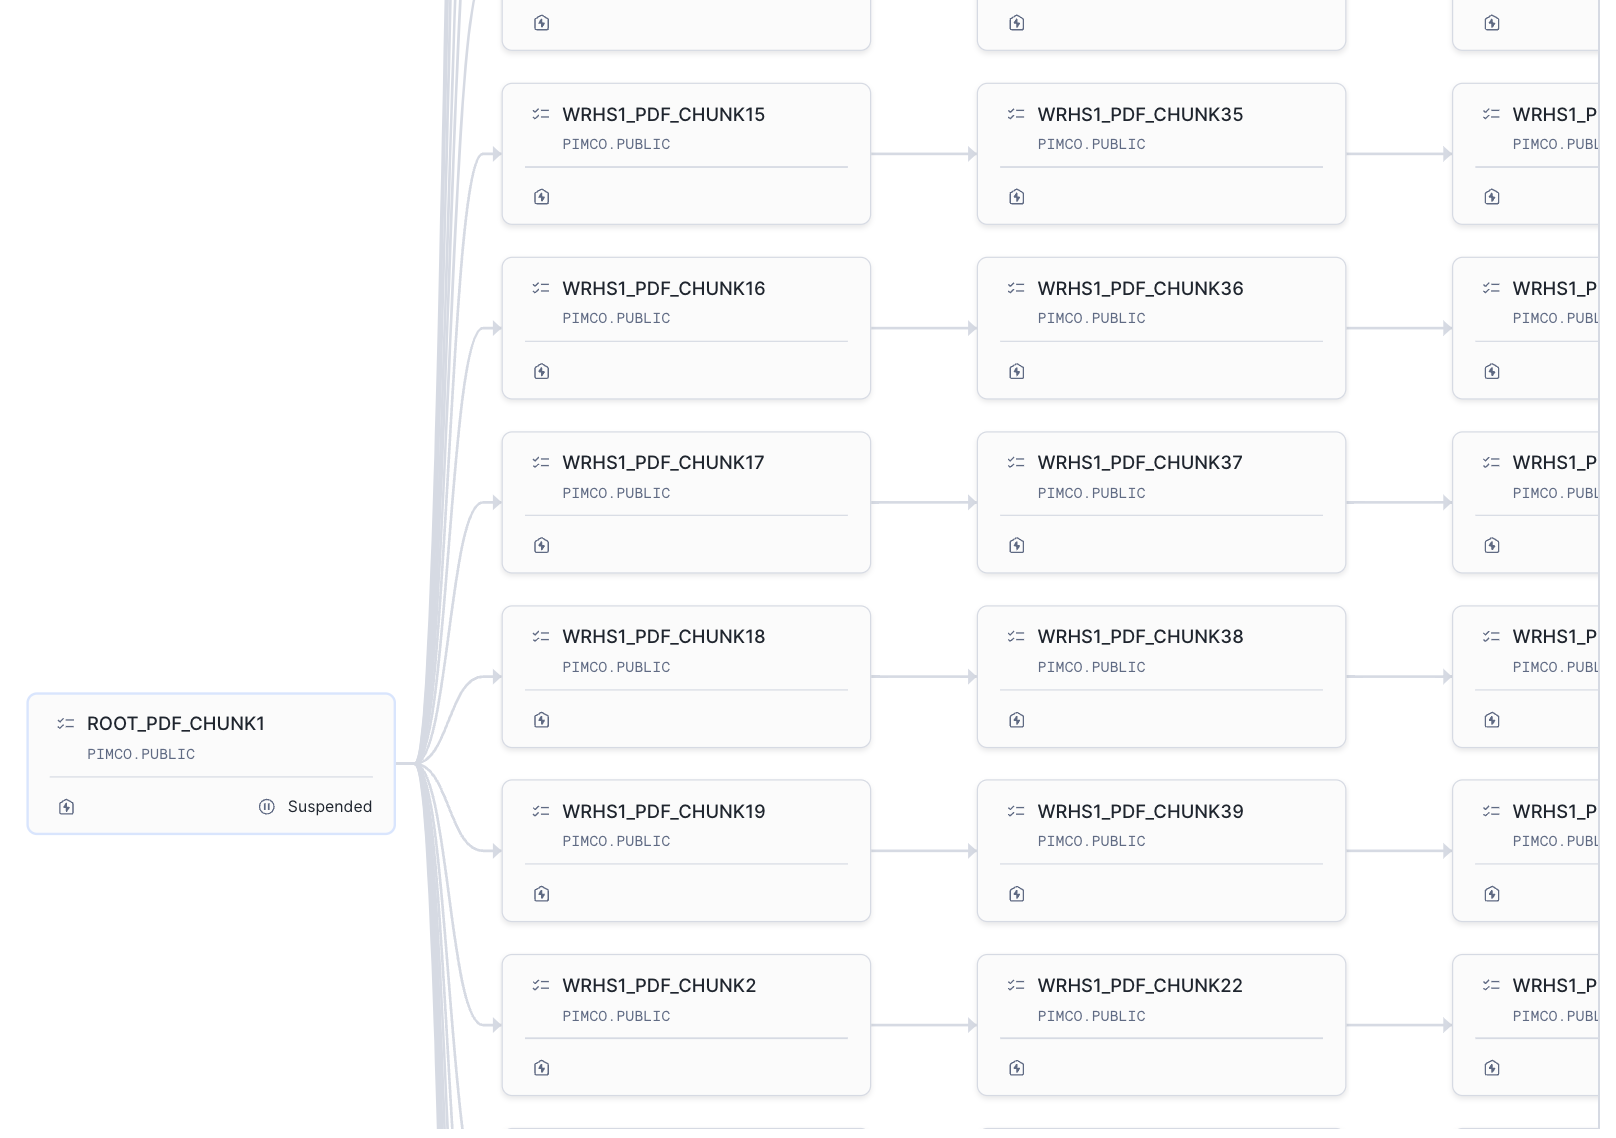

In [20]:
from IPython.display import Image
Image(filename='DAG20202020.png') 

### Resume all child tasks and execute the parent tasks.
#### Assume There are 100 parent tasks and each parent task has 80 child tasks == Total of 8100 tasks will execute across 100 warehouse

In [21]:
resume_tasks = '''alter task {0} resume;'''
for index, row in exec_df.iterrows():
    session.sql(resume_tasks.format('WRHS'+str(row['wrhs_batch'])+ '_'+row['task'])).collect()

# STOP HERE and validate the tasks in Snowflake DB before you proceed with next step

In [23]:
# for row in batch.to_local_iterator():
execute_parent_task = '''execute task ROOT_PDF_CHUNK{0};'''
for index,row in batch.iterrows():
    session.sql(execute_parent_task.format(row['WRHS_BATCH'])).collect()

### Monitor Warehouse Usage on Snowflake

### When All tasks are fully active

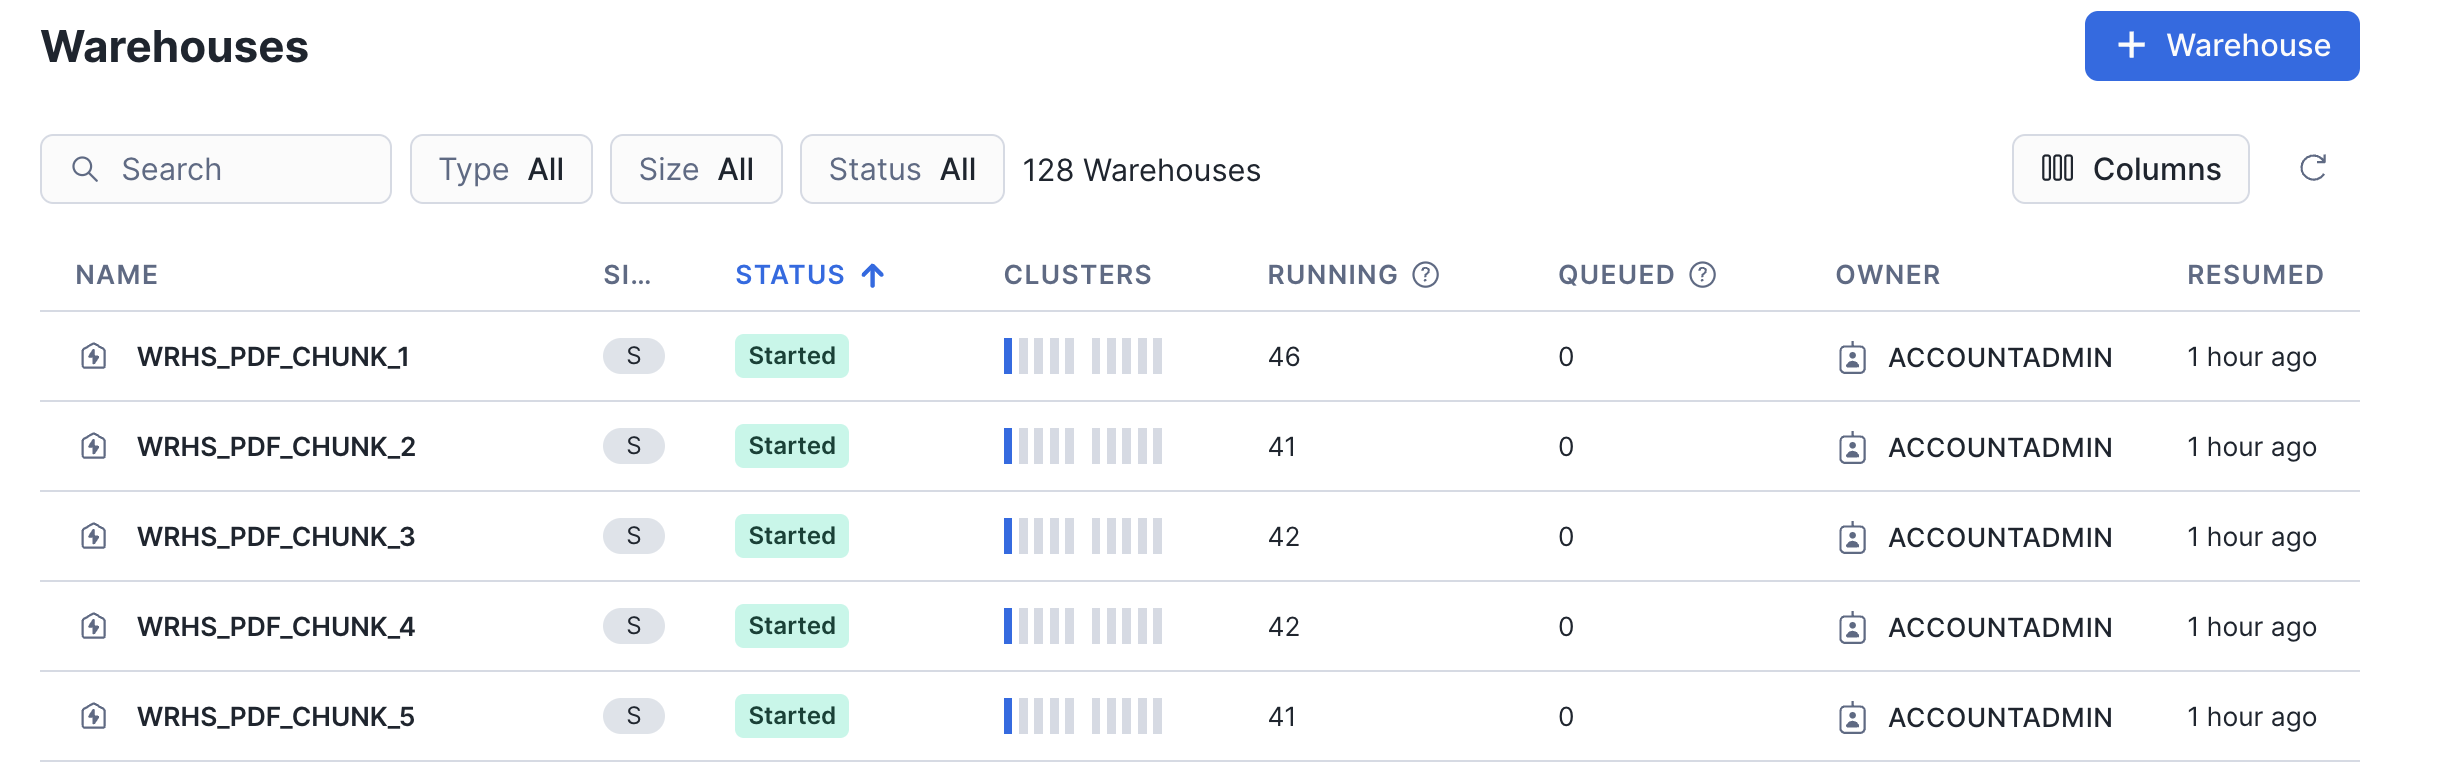

In [43]:
from IPython.display import Image
Image(filename='MultiCluster warehouse Begin.png') 

### Monitor Load Execution

In [35]:
exec_monitor = '''SELECT 
'XS Multi Cluster' as Warehouse_size,
c.total_pdf_files,
round(c.avg_pdf_size)/1000000 as avg_pdf_size_in_mb,
b.records as total_embed_chunks, 
timestampdiff('minutes', query_start_time,nvl(completed_time,current_timestamp))  elapsed_mins,
name, 
query_start_time, 
completed_time,
root_task_id
FROM TABLE(INFORMATION_SCHEMA.TASK_HISTORY()) 
join 
(select COUNT(*) as records from test_chunks) b
join
(select count(*) as total_pdf_files, avg(size) avg_pdf_size from directory(@rag_docs)) c
where 
databasE_name = 'PIMCO' and
completed_time is null
ORDER BY query_start_time asc
limit 1'''
session.sql(exec_monitor).show()

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|"WAREHOUSE_SIZE"  |"TOTAL_PDF_FILES"  |"AVG_PDF_SIZE_IN_MB"  |"TOTAL_EMBED_CHUNKS"  |"ELAPSED_MINS"  |"NAME"             |"QUERY_START_TIME"                |"COMPLETED_TIME"                  |"ROOT_TASK_ID"                        |
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
|XS Multi Cluster  |10001              |4.748494              |5574263               |19              |WRHS2_PDF_CHUNK43  |2024-05-05 16:26:36.683000-07:00  |2024-05-05 16:45:45.860000-07:00  |01b42250-6a87-d6fd-0000-00000000214f  |
--------------------------------------------------------------------

In [33]:
tasks_monitor = '''SELECT
NAME, STATE, QUERY_START_TIME,
timestampdiff('minutes', query_start_time,nvl(completed_time,current_timestamp))  elapsed_mins
FROM
  table(
    "PIMCO".INFORMATION_SCHEMA.TASK_HISTORY()
  )
WHERE
  schema_name = 'PUBLIC'
  AND database_name = 'PIMCO'
  and QUERY_START_TIME >=(
SELECT
max(QUERY_START_TIME)
FROM
  table(
    "PIMCO".INFORMATION_SCHEMA.TASK_HISTORY(
      task_name => 'ROOT_PDF_CHUNK5')
  )
WHERE
  schema_name = 'PUBLIC'
  AND database_name = 'PIMCO')
  ORDER BY NAME'''
session.sql(tasks_monitor).show(100)

-------------------------------------------------------------------------------------
|"NAME"             |"STATE"    |"QUERY_START_TIME"                |"ELAPSED_MINS"  |
-------------------------------------------------------------------------------------
|WRHS1_PDF_CHUNK62  |EXECUTING  |2024-05-05 16:45:08.347000-07:00  |17              |
|WRHS1_PDF_CHUNK63  |SUCCEEDED  |2024-05-05 16:43:24.418000-07:00  |18              |
|WRHS1_PDF_CHUNK64  |SUCCEEDED  |2024-05-05 16:42:36.728000-07:00  |18              |
|WRHS1_PDF_CHUNK65  |EXECUTING  |2024-05-05 16:44:58.326000-07:00  |18              |
|WRHS1_PDF_CHUNK66  |EXECUTING  |2024-05-05 16:45:06.694000-07:00  |17              |
|WRHS1_PDF_CHUNK67  |SUCCEEDED  |2024-05-05 16:43:11.769000-07:00  |19              |
|WRHS1_PDF_CHUNK68  |SUCCEEDED  |2024-05-05 16:43:56.821000-07:00  |18              |
|WRHS1_PDF_CHUNK69  |SUCCEEDED  |2024-05-05 16:43:34.410000-07:00  |19              |
|WRHS1_PDF_CHUNK70  |SUCCEEDED  |2024-05-05 16:44:48.4

### Check the final table loaded with all the embeddings

In [40]:
session.sql("select * from test_chunks limit 10").to_pandas()

,RELATIVE_PATH,SIZE,chunks,CHUNK_EMBEDDING
0,dictionary copy 1270.pdf,4748494,A Concise Dictionaryof Old I celandic Fonts b ...,"[-0.004715647, -0.010378069, -0.032320295, -0...."
1,dictionary copy 1270.pdf,4748494,"af höfuðit, the head f lew o ff; (3) of, among...","[-0.039308544, 0.0031773655, -0.04232415, -0.0..."
2,dictionary copy 1270.pdf,4748494,"abat e- ment ; selja e -t með af föllum, to se...","[-0.046273097, -0.016226724, -0.021249235, -0...."
3,dictionary copy 1270.pdf,4748494,"c.,to earn (aflaði h ann þar f é mikit); r efl...","[-0.022484973, -0.02776462, -0.019744078, -0.0..."
4,dictionary copy 1270.pdf,4748494,"law ;-má(seemá), v.to blot out , destr oy;-mœð...","[-0.021791492, -0.018467724, -0.029449428, -0...."
5,dictionary copy 1270.pdf,4748494,"af þ essum ófriði); (4) rumour , notic e(fá nö...","[-0.033551354, -0.019349668, -0.040594406, -0...."
6,dictionary copy 1270.pdf,4748494,in a vehic le (fóruþeir í sleðann ok ók u alla...,"[-0.0116294185, -0.03144217, -0.020250374, -0...."
7,dictionary copy 1270.pdf,4748494,"út b era arn þ etta,this c hild shall not be b...","[-0.026131812, -0.015249908, -0.02753632, -0.0..."
8,dictionary copy 1270.pdf,4748494,"and ever ; after a neg ation, ever(þvílí- ka g...","[-0.056571327, -0.046079744, -0.029740069, -0...."
9,dictionary copy 1270.pdf,4748494,alin (gen. sing .alnarorálnar; pl. alnarorálni...,"[-0.027617715, -0.020630065, -0.033530124, -0...."


### When the tasks have completed and very few tasks left, See how the clusters scale down

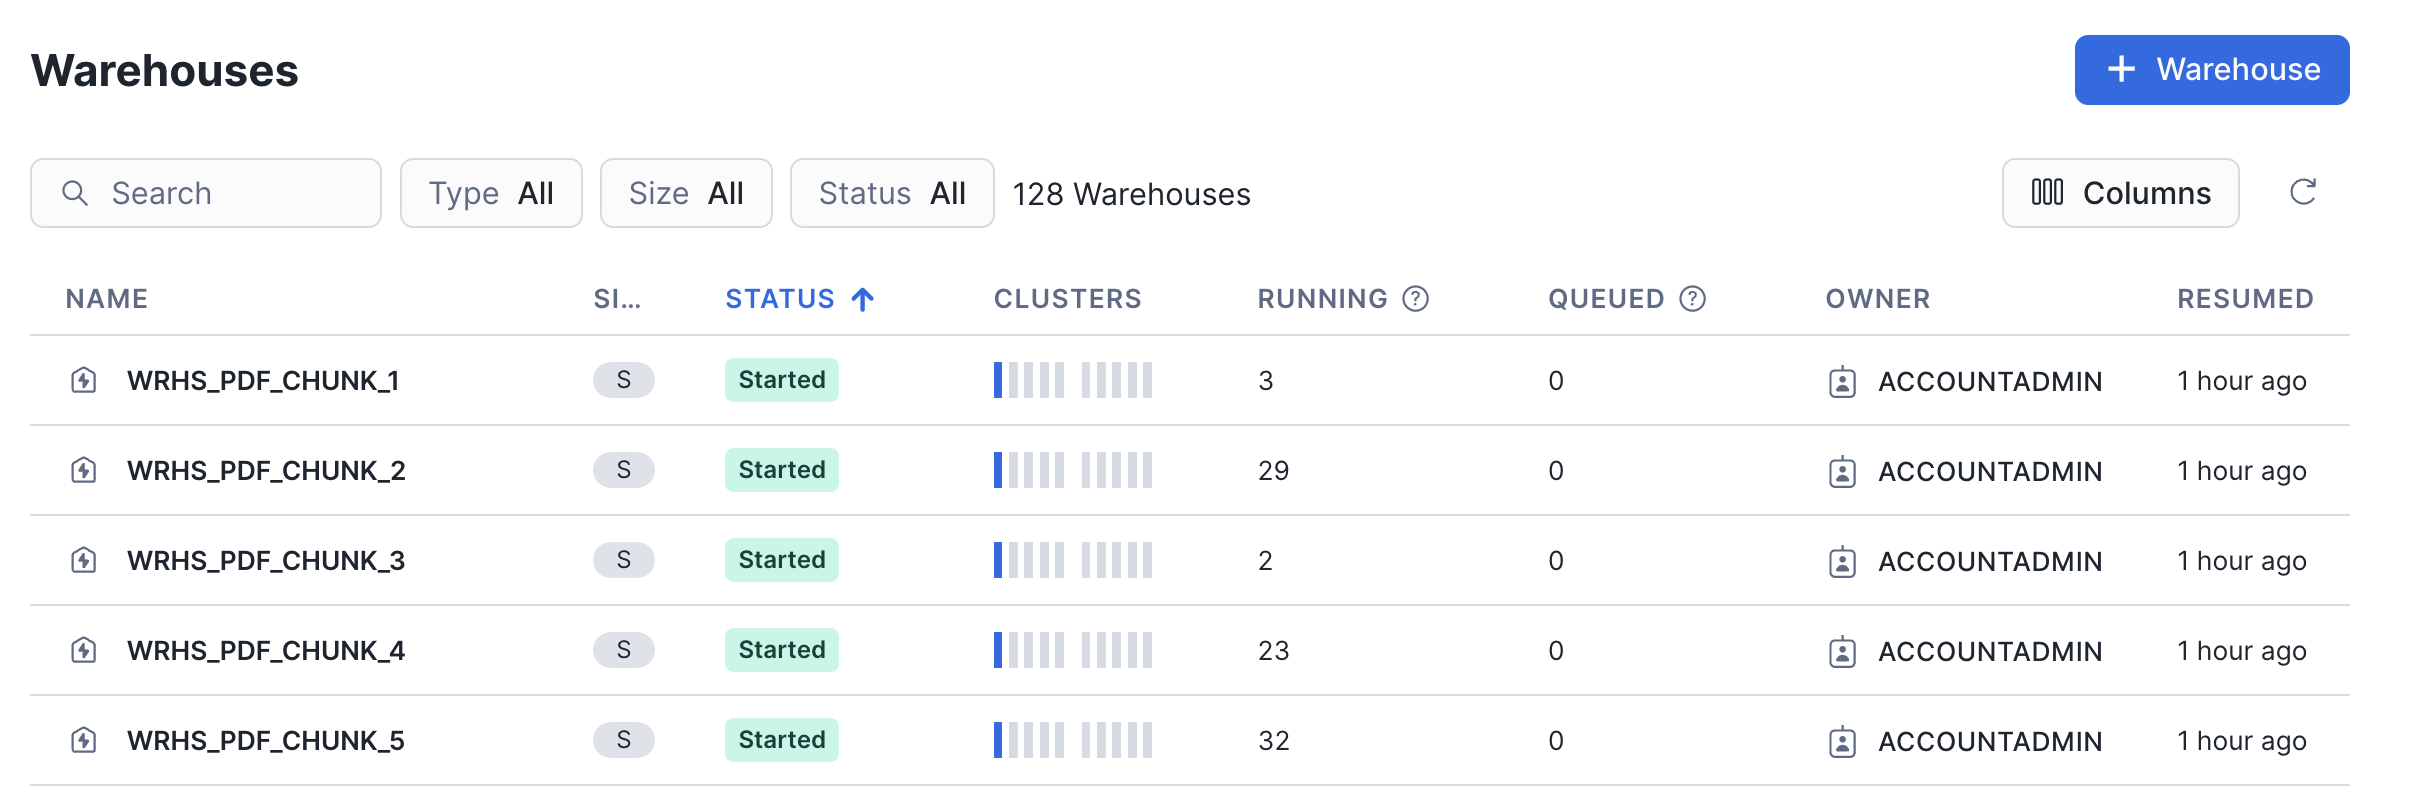

In [42]:
from IPython.display import Image
Image(filename='MultiCluster warehouse End.png')

In [2]:
session.close()